# **Mental Health in Tech Survey - EDA**


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** [Your Name]


# **Project Summary -**

This project explores the 2014 Mental Health in Tech survey, which captures 1,259 responses from tech and non-tech employees on their attitudes toward mental health, whether they have sought treatment, and how supportive (or unsupportive) their workplace is. The dataset has 27 columns covering demographics (Age, Gender, Country, US state), employment context (company size, remote work, whether the employer is a tech company), and a series of workplace-support questions (benefits, care options, anonymity, ease of taking leave, and perceived consequences of disclosing a mental health issue).

The data required real cleaning before analysis: Age contained invalid entries (negative numbers and one 100-billion-year-old respondent), and Gender was entered as free text with over 40 distinct spellings ("Male", "m", "Cis Male", "woman", "non-binary", etc.) that were consolidated into Male / Female / Other. Several columns (state, self_employed, work_interfere, comments) had missing values, most heavily in `comments` (87%) and `state` (41%, since it only applies to US respondents).

The core question this EDA investigates is what's associated with someone having sought treatment for a mental health condition (the `treatment` column), since that's the clearest behavioural signal in the dataset. Across 15 charts, the analysis looks at how treatment-seeking varies by family history, gender, workplace support (benefits, care options, anonymity protections), company size, and geography. The headline findings: family history of mental illness and self-reported work interference are the two strongest correlates of treatment-seeking (correlation of 0.38 and 0.49 with treatment respectively), while company-provided benefits and clarity around care options show a real but smaller positive association. Company size and remote-work status show almost no relationship with treatment-seeking. Gender shows a notable gap: women and non-binary/other respondents in this sample sought treatment at meaningfully higher rates than men.

These findings point to a practical business takeaway for employers: clear communication about mental health benefits and care options is associated with higher treatment-seeking, which suggests investment in this kind of transparency (not just the benefit itself) may help close the gap for employees who need support but aren't accessing it.


# **GitHub Link -**

*(Add your GitHub repository link here once you upload this notebook.)*


# **Problem Statement**


Mental health remains under-discussed and under-supported in many tech workplaces, despite its impact on productivity and employee wellbeing. This project analyzes the 2014 OSMI (Open Sourcing Mental Illness) survey to understand current attitudes toward mental health in the tech industry, identify which employees are more likely to seek treatment, and surface which workplace factors (benefits, anonymity, leave policy, company size) are associated with that behaviour.


#### **Define Your Business Objective?**

To identify the workplace and demographic factors most strongly associated with an employee seeking treatment for a mental health condition, so that employers can design more effective mental health support programs and identify gaps in current benefits communication.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('survey.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 1259
Columns: 27


### Dataset Information

In [5]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending=False)


comments                     1095
state                         515
work_interfere                264
self_employed                  18
Gender                          0
Timestamp                       0
Age                             0
family_history                  0
treatment                       0
no_employees                    0
Country                         0
remote_work                     0
tech_company                    0
care_options                    0
benefits                        0
seek_help                       0
anonymity                       0
leave                           0
wellness_program                0
mental_health_consequence       0
phys_health_consequence         0
supervisor                      0
coworkers                       0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
dtype: int64

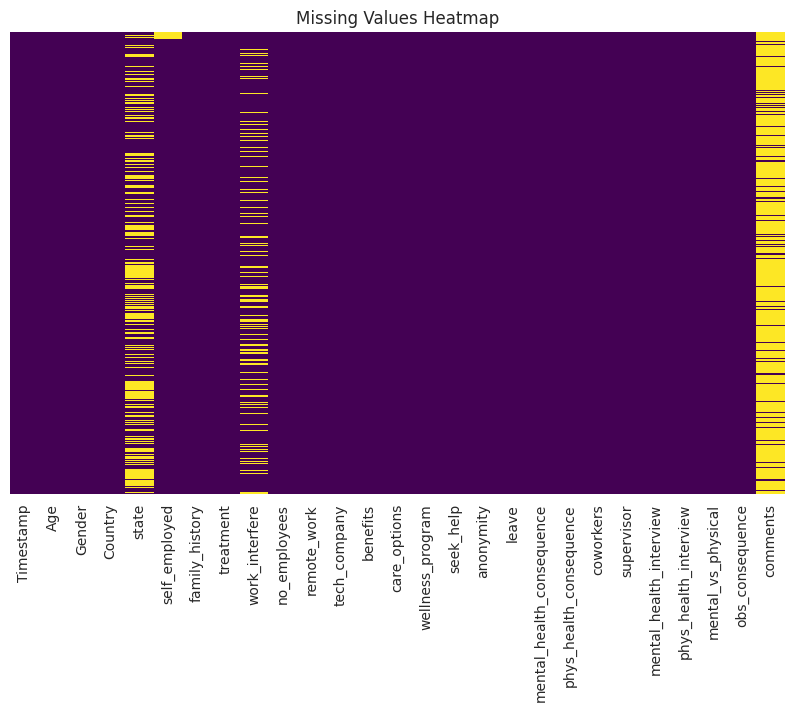

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()


### What did you know about your dataset?

The dataset has 1,259 rows and 27 columns with **no duplicate rows**. Most columns are categorical (survey responses like Yes/No/Maybe). Four columns have missing values: `comments` (1,095 missing, ~87% — an optional free-text field), `state` (515 missing, ~41% — only applies to respondents based in the US), `work_interfere` (264 missing, ~21% — only applies to respondents who have a mental health condition), and `self_employed` (18 missing, ~1%). The `Age` column also contains clearly invalid entries (negative numbers and an impossible value of 100 billion) that need cleaning before analysis, and `Gender` was collected as free text with over 40 inconsistent spellings that need to be standardized.


## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()


['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

The dataset mixes a few numeric/free-text fields (Timestamp, Age, Gender, Country, state, comments) with 21 categorical survey questions, almost all answered as Yes/No/Maybe/Don't know or similar small option sets. The target of interest for this analysis, `treatment` (has the respondent sought treatment for a mental health condition), is a simple Yes/No column and is almost perfectly balanced: 637 Yes vs 622 No.


### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Timestamp: 1246 unique values
Age: 53 unique values
Gender: 49 unique values
Country: 48 unique values
state: 45 unique values
self_employed: 2 unique values
family_history: 2 unique values
treatment: 2 unique values
work_interfere: 4 unique values
no_employees: 6 unique values
remote_work: 2 unique values
tech_company: 2 unique values
benefits: 3 unique values
care_options: 3 unique values
wellness_program: 3 unique values
seek_help: 3 unique values
anonymity: 3 unique values
leave: 5 unique values
mental_health_consequence: 3 unique values
phys_health_consequence: 3 unique values
coworkers: 3 unique values
supervisor: 3 unique values
mental_health_interview: 3 unique values
phys_health_interview: 3 unique values
mental_vs_physical: 3 unique values
obs_consequence: 2 unique values
comments: 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1. Fix invalid Age values (negatives, and unrealistic values like 100 billion)
# Replace anything outside a sane working-age range with the median age
age_median = df.loc[(df['Age'] >= 15) & (df['Age'] <= 80), 'Age'].median()
df.loc[(df['Age'] < 15) | (df['Age'] > 80), 'Age'] = age_median

# 2. Standardize Gender into Male / Female / Other
def clean_gender(g):
    g = str(g).strip().lower()
    male_terms = ['male', 'm', 'man', 'cis male', 'male-ish', 'maile', 'cis man', 'malr',
                  'mal', 'make', 'msle', 'mail', 'guy (-ish) ^_^', 'male (cis)',
                  'something kinda male?', 'male leaning androgynous',
                  'ostensibly male, unsure what that really means']
    female_terms = ['female', 'f', 'woman', 'cis female', 'femake', 'female (cis)',
                     'femail', 'cis-female/femme', 'female (trans)', 'trans woman',
                     'trans-female']
    if g in male_terms:
        return 'Male'
    if g in female_terms:
        return 'Female'
    return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# 3. Fill missing work_interfere with 'Not applicable' (these are respondents without
#    a mental health condition, so the question genuinely doesn't apply to them)
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')

# 4. Fill missing self_employed with the mode (tiny number of nulls)
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

# 5. Drop columns that aren't useful for this analysis
#    (state is US-only and mostly null; comments is free text; Timestamp isn't analysed here)
df.drop(columns=['comments', 'Timestamp'], inplace=True)

df.head()


,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,IL,No,No,Yes,Often,6-25,No,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,IN,No,No,No,Rarely,More than 1000,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,No,Rarely,6-25,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,NaN,No,Yes,Yes,Often,26-100,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,TX,No,No,No,Never,100-500,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


### What all manipulations have you done and insights you found?

Three main issues were fixed: (1) invalid `Age` values (negative numbers and one absurd 100-billion entry) were replaced with the median age of respondents in a realistic 15-80 range; (2) `Gender` free-text responses were consolidated from 40+ spellings down to Male / Female / Other, which is what makes gender-based comparisons possible later; (3) missing `work_interfere` values were filled with 'Not applicable' rather than dropped, since a missing value here specifically means the respondent doesn't have a mental health condition — dropping those rows would have thrown away 264 valid responses and biased the dataset toward only people who do have a condition. `comments` and `Timestamp` were dropped since they aren't used in this analysis (comments is mostly-null free text, Timestamp isn't a variable of analytical interest here).


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

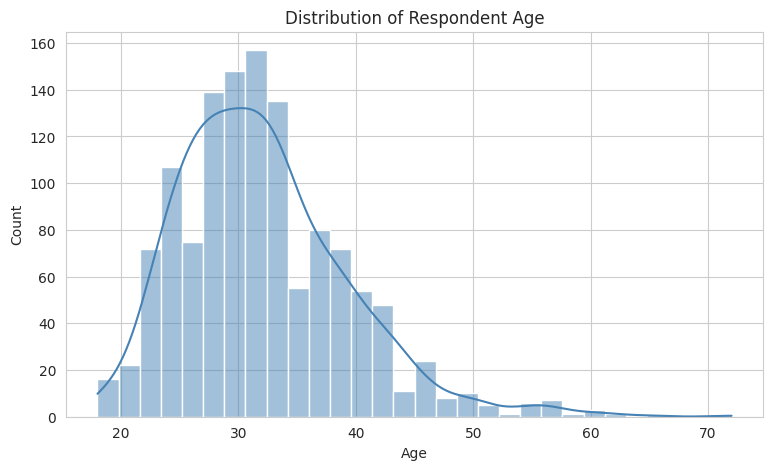

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(9,5))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard choice for understanding the shape, center, and spread of a single continuous variable like Age.


##### 2. What is/are the insight(s) found from the chart?

The respondent base is heavily concentrated in the 25-35 age range, with a peak around age 29-30. This is a young workforce sample, consistent with the tech industry's typical age profile, and skews slightly right (a smaller tail of older respondents up to their 60s).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is mainly descriptive/contextual rather than directly actionable, but it matters for interpreting every other chart: findings here reflect a predominantly early-to-mid-career population, so conclusions may not generalize as well to a workforce with an older age profile.


#### Chart - 2

/tmp/ipykernel_153/1275489639.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', order=order, palette='viridis')


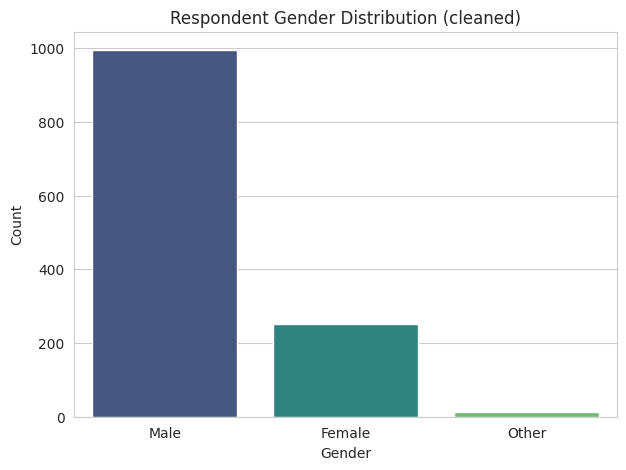

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(7,5))
order = df['Gender'].value_counts().index
sns.countplot(data=df, x='Gender', order=order, palette='viridis')
plt.title('Respondent Gender Distribution (cleaned)')
plt.ylabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

A count plot clearly shows category sizes for a cleaned categorical variable, and ordering by frequency makes the imbalance immediately visible.


##### 2. What is/are the insight(s) found from the chart?

After cleaning, the sample is heavily male-skewed: 995 Male vs 251 Female vs 13 Other (roughly 79% / 20% / 1%). This is an important caveat for any gender-based comparison later in the analysis — the Female and Other groups are much smaller samples, so their statistics carry more uncertainty.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Not directly a business action, but it's a critical caveat for the business objective: any recommendation drawn from gender comparisons should be read with the sample imbalance in mind, and a follow-up survey with better gender representation would strengthen confidence in those specific findings.


#### Chart - 3

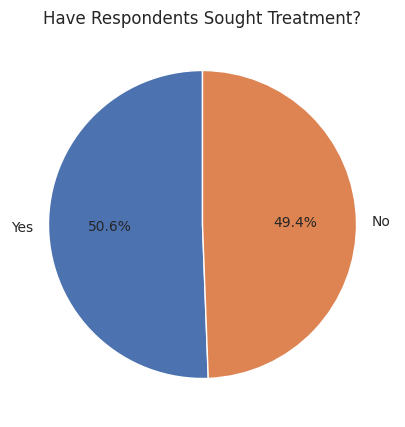

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(6,5))
df['treatment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0','#DD8452'], startangle=90)
plt.title('Have Respondents Sought Treatment?')
plt.ylabel('')
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart works well here specifically because this is the key binary outcome variable of the whole analysis, and a simple proportion split is the clearest way to introduce it before comparing it against other factors.


##### 2. What is/are the insight(s) found from the chart?

The sample is almost perfectly balanced: 637 respondents (50.6%) have sought treatment vs 622 (49.4%) who have not. This balance is convenient for analysis, since it means differences seen when splitting by other variables (gender, benefits, etc.) are meaningful rather than an artifact of an imbalanced target.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This balance is good news for the business objective: it means the workplace/demographic factors explored in the rest of this analysis can be compared fairly without needing to correct for class imbalance.


#### Chart - 4

<Figure size 700x500 with 0 Axes>

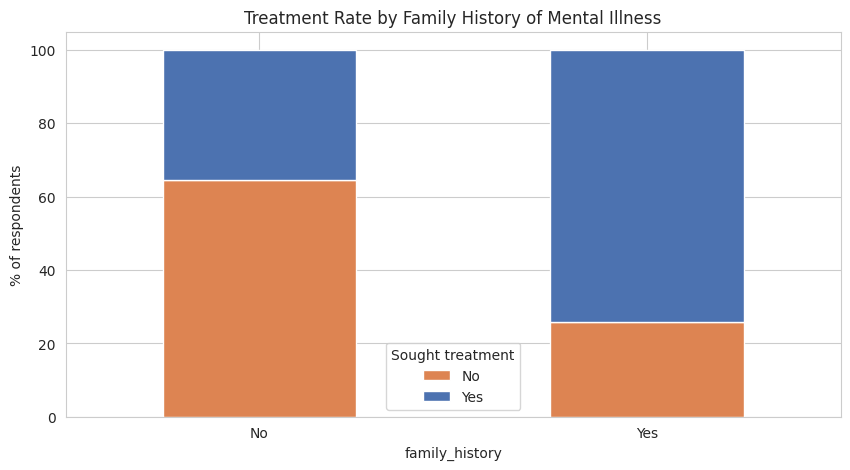

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(7,5))
pd.crosstab(df['family_history'], df['treatment'], normalize='index').mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Family History of Mental Illness')
plt.ylabel('% of respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

A 100%-stacked bar chart is ideal for comparing how a proportion (treatment rate) shifts across the two categories of a binary variable (family history).


##### 2. What is/are the insight(s) found from the chart?

Family history has a large effect: 74.2% of respondents with a family history of mental illness have sought treatment, compared to just 35.5% of those without one — a 39 percentage-point gap. This is the strongest single relationship found in the whole dataset (correlation of 0.38 with treatment).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is highly actionable: employees with a known family history are far more likely to already be engaged with treatment, which employers could use to inform targeted, opt-in awareness campaigns (e.g. highlighting benefits specifically to at-risk groups) rather than one-size-fits-all messaging. No negative growth risk identified here.


#### Chart - 5

<Figure size 700x500 with 0 Axes>

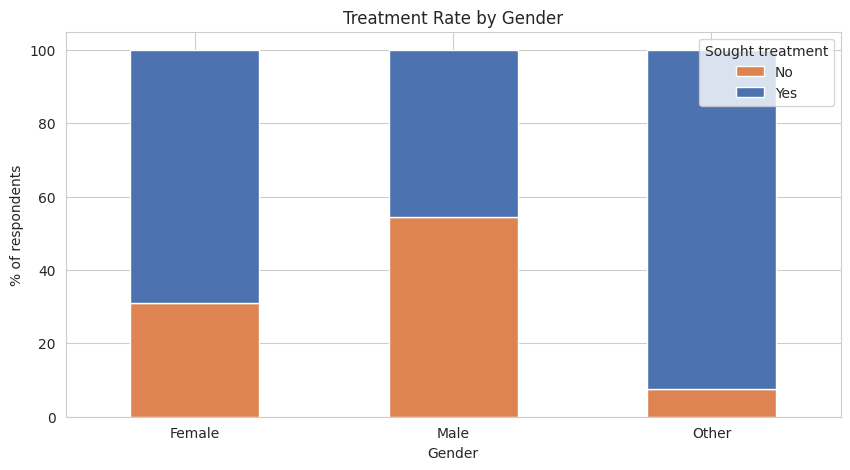

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(7,5))
pd.crosstab(df['Gender'], df['treatment'], normalize='index').mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Gender')
plt.ylabel('% of respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

Same stacked-percentage approach as Chart 4, to keep the comparison method consistent across categorical predictors of the treatment outcome.


##### 2. What is/are the insight(s) found from the chart?

There's a clear gender gap: 68.9% of Female respondents and 92.3% of Other-gender respondents have sought treatment, compared to only 45.4% of Male respondents. Keep in mind the Other group is very small (13 people), so that 92.3% figure is less statistically reliable than the Male/Female comparison.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this suggests men in tech may be under-seeking treatment relative to their female and non-binary colleagues, which could point to a stigma or awareness gap worth addressing specifically for male employees (e.g. targeted messaging or manager training). No negative growth interpretation applies here.


#### Chart - 6

/tmp/ipykernel_153/719069047.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')


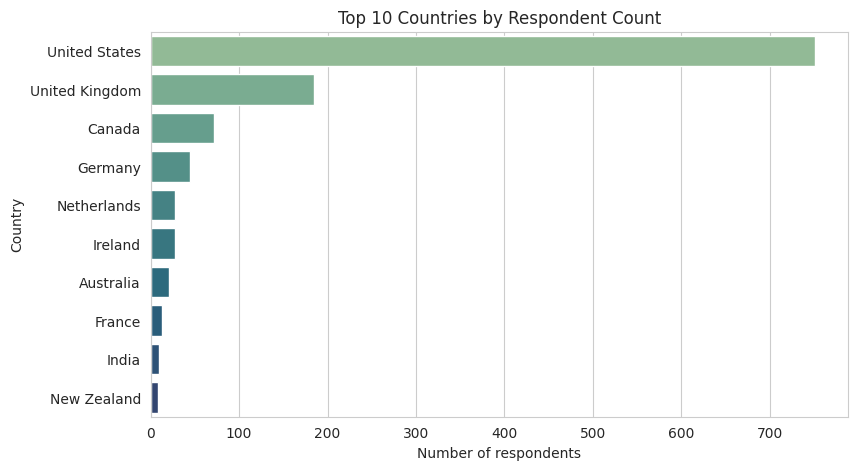

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(9,5))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')
plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Number of respondents')
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart handles the long country names cleanly and ranks them clearly by frequency, which a pie chart or vertical bars would make harder to read.


##### 2. What is/are the insight(s) found from the chart?

The dataset is dominated by the United States (751 respondents, ~60%) and the United Kingdom (185, ~15%), with Canada (72), Germany (45) and a long tail of other countries making up the rest. This geographic concentration is important context for the business objective's geography-related inspiration question.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This limits how confidently findings can be generalized globally — recommendations from this data mainly reflect US/UK workplace norms and healthcare systems (e.g. US health insurance ties to employment), so applying conclusions to other regions without local data could be misleading.


#### Chart - 7

/tmp/ipykernel_153/177819592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='work_interfere', order=order, palette='mako')


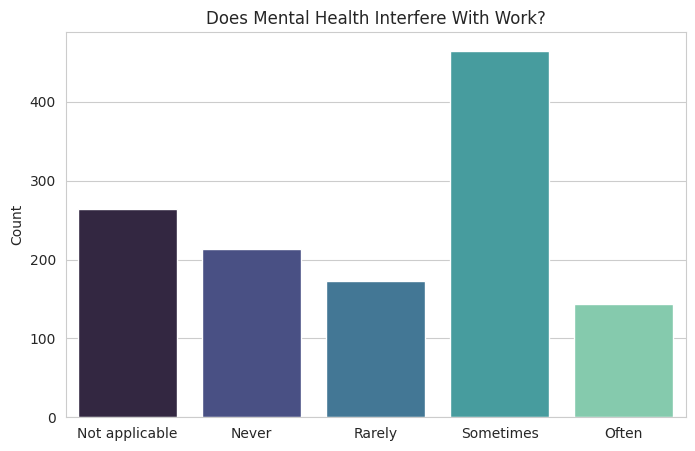

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
order = ['Not applicable','Never','Rarely','Sometimes','Often']
sns.countplot(data=df, x='work_interfere', order=order, palette='mako')
plt.title('Does Mental Health Interfere With Work?')
plt.xlabel('')
plt.ylabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

A count plot in a logical ordinal sequence (Not applicable -> Never -> ... -> Often) makes it easy to read this as a severity spectrum rather than an arbitrary category list.


##### 2. What is/are the insight(s) found from the chart?

'Sometimes' is the most common response (465 respondents) among those with a condition, and 'Often' (144) still outnumbers 'Never' (213) combined with the 264 'Not applicable' respondents who don't have a condition at all. This shows work interference is a frequent, not occasional, experience among affected employees.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is a strong signal that mental health directly affects productivity for a large share of employees, reinforcing the business case for investing in support programs, not just as a wellbeing perk but as a productivity lever.


#### Chart - 8

<Figure size 900x500 with 0 Axes>

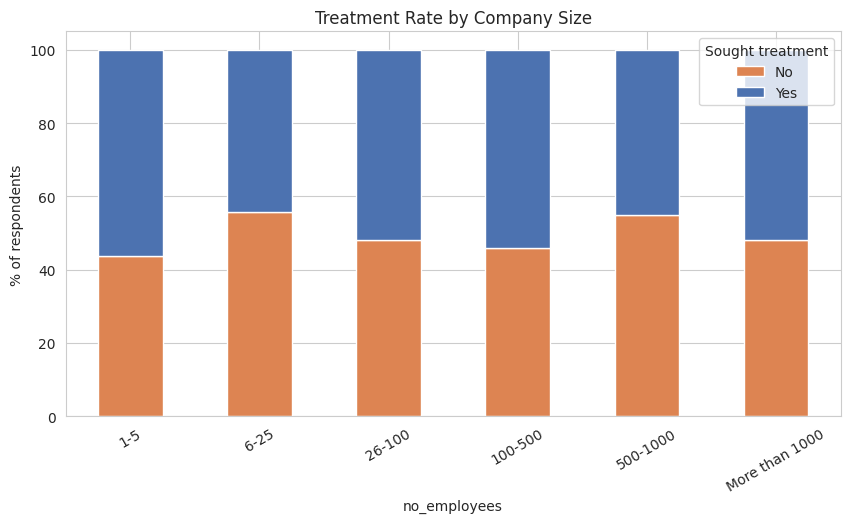

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(9,5))
order = ['1-5','6-25','26-100','100-500','500-1000','More than 1000']
pd.crosstab(df['no_employees'], df['treatment'], normalize='index').loc[order].mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Company Size')
plt.ylabel('% of respondents')
plt.xticks(rotation=30)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

A stacked percentage bar chart, ordered from smallest to largest company size, makes any trend across company size immediately visible.


##### 2. What is/are the insight(s) found from the chart?

Treatment rate is fairly flat across company sizes, ranging narrowly from 44.1% (6-25 employees) to 56.2% (1-5 employees) — there's no clear trend where bigger or smaller companies see meaningfully higher treatment-seeking. Company size alone doesn't appear to be a strong driver.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful negative finding: employers shouldn't assume that company size (and by extension, more formal HR structure) alone solves the mental health support gap — the data suggests other factors (like benefits clarity, discussed next) matter more than headcount.


#### Chart - 9

<Figure size 700x500 with 0 Axes>

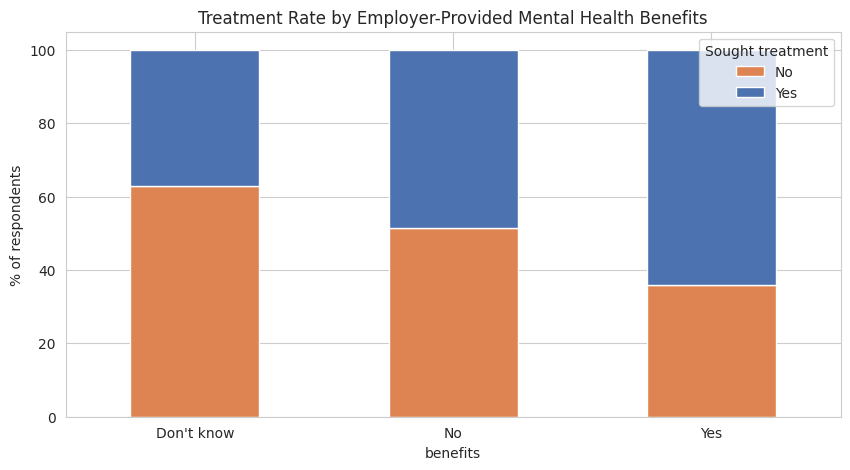

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(7,5))
pd.crosstab(df['benefits'], df['treatment'], normalize='index').mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Employer-Provided Mental Health Benefits')
plt.ylabel('% of respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

Same stacked-percentage format, kept consistent with the other workplace-support comparisons so the reader can compare effect sizes across charts directly.


##### 2. What is/are the insight(s) found from the chart?

Respondents whose employer provides mental health benefits sought treatment at 63.9%, versus 48.4% when benefits are absent and just 37.0% when the respondent doesn't even know if benefits exist. That last group is notable — not knowing has a similar (or worse) effect than there being no benefit at all.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, directly actionable: simply offering a benefit isn't enough if employees don't know about it. The gap between 'No' (48.4%) and 'Don't know' (37.0%) suggests employers should invest as much in communicating existing benefits as in creating them.


#### Chart - 10

<Figure size 700x500 with 0 Axes>

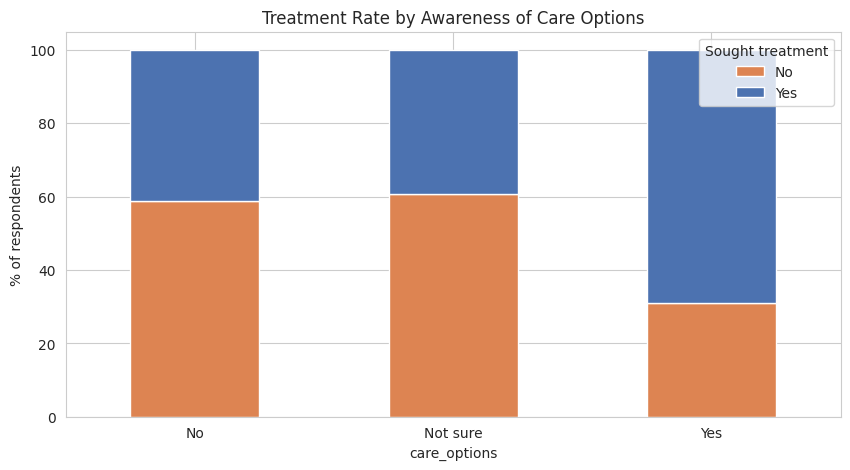

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(7,5))
pd.crosstab(df['care_options'], df['treatment'], normalize='index').mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Awareness of Care Options')
plt.ylabel('% of respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

Kept consistent with Charts 4, 5, 8 and 9 so all workplace/demographic predictors of treatment are visually comparable using the same chart type.


##### 2. What is/are the insight(s) found from the chart?

Knowing your care options is one of the strongest workplace-support predictors found: 69.1% of respondents who know their care options sought treatment, vs 41.3% who said no and 39.2% who are 'not sure'. This mirrors the benefits finding — awareness matters as much as availability.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this reinforces the same actionable insight as Chart 9: clear, repeated communication of what mental health care options exist is associated with meaningfully higher treatment-seeking, and is a low-cost lever compared to adding new benefits entirely.


#### Chart - 11

<Figure size 700x500 with 0 Axes>

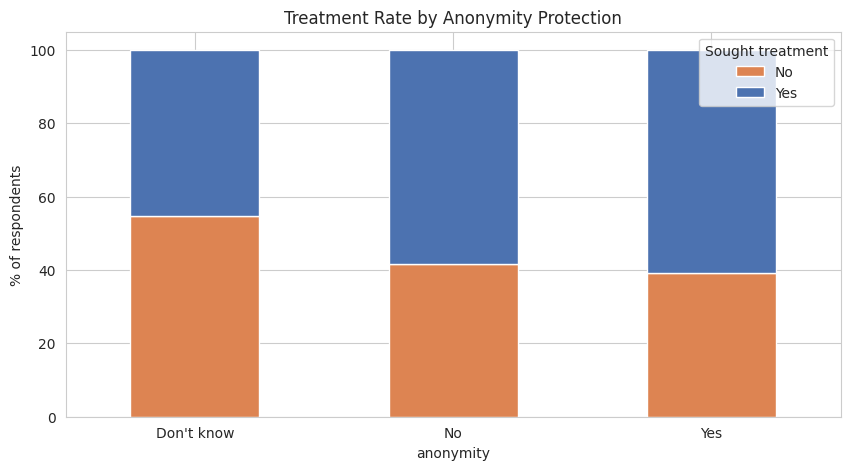

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(7,5))
pd.crosstab(df['anonymity'], df['treatment'], normalize='index').mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Anonymity Protection')
plt.ylabel('% of respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

Consistent stacked-percentage format with the other workplace-support charts for direct visual comparison of effect size.


##### 2. What is/are the insight(s) found from the chart?

The effect here is smaller than benefits or care options: 60.8% treatment rate when anonymity is protected vs 58.5% when it's not, and 45.3% when the respondent doesn't know. The 'don't know' gap exists but is less pronounced than in the benefits/care-options charts.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mildly actionable — anonymity awareness matters somewhat, but less than clarity on benefits and care options. It's a lower-priority lever compared to the findings in Charts 9 and 10, so employers should focus communication budget there first.


#### Chart - 12

<Figure size 900x500 with 0 Axes>

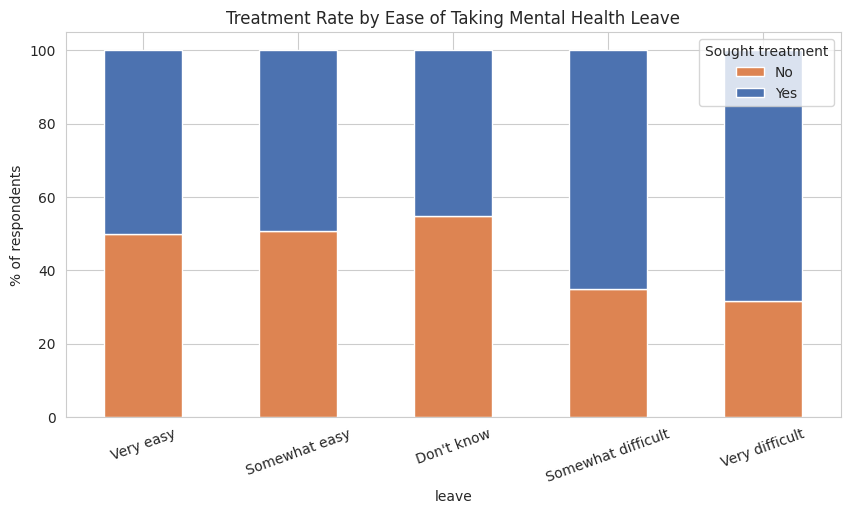

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(9,5))
order = ['Very easy','Somewhat easy',"Don't know",'Somewhat difficult','Very difficult']
pd.crosstab(df['leave'], df['treatment'], normalize='index').loc[order].mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Ease of Taking Mental Health Leave')
plt.ylabel('% of respondents')
plt.xticks(rotation=20)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

Ordering categories from 'Very easy' to 'Very difficult' turns this into a readable spectrum, making any non-obvious (non-linear) pattern easy to spot.


##### 2. What is/are the insight(s) found from the chart?

Counter-intuitively, treatment-seeking is highest among those who find leave 'Very difficult' (68.4%) or 'Somewhat difficult' (65.1%) to take — higher than those who find it 'Very easy' (50.0%). This likely isn't leave difficulty causing treatment; more plausibly, people who already have a diagnosed/more severe condition are both more likely to have sought treatment AND more attuned to how hard leave would be to take.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful nuance for interpretation: it would be a mistake to read this as 'making leave harder increases treatment-seeking.' The likely causal direction is reversed, so this chart is more of a flag for correlation-vs-causation caution than a direct action item.


#### Chart - 13

<Figure size 700x500 with 0 Axes>

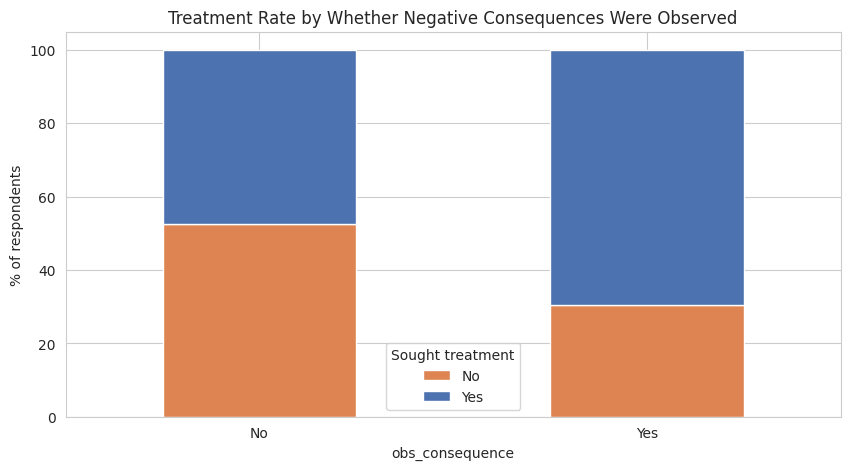

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(7,5))
pd.crosstab(df['obs_consequence'], df['treatment'], normalize='index').mul(100).plot(kind='bar', stacked=True, color=['#DD8452','#4C72B0'])
plt.title('Treatment Rate by Whether Negative Consequences Were Observed')
plt.ylabel('% of respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought treatment')
plt.show()


##### 1. Why did you pick the specific chart?

Same consistent stacked-bar format, closing out the workplace-culture comparisons alongside benefits, care options, anonymity, and leave.


##### 2. What is/are the insight(s) found from the chart?

Respondents who have observed negative consequences for coworkers disclosing mental health issues sought treatment at a higher rate themselves (69.6%) than those who haven't observed such consequences (47.3%). This is likely because both stem from working somewhere the topic is visibly present/discussed, rather than the negative consequences themselves encouraging treatment.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indirectly actionable: witnessing negative consequences correlates with a workplace where mental health is a live, visible topic — which cuts both ways. It reinforces that psychological safety around discussing mental health (not just benefits on paper) is a meaningful cultural factor worth measuring and improving.


#### Chart - 14 - Correlation Heatmap

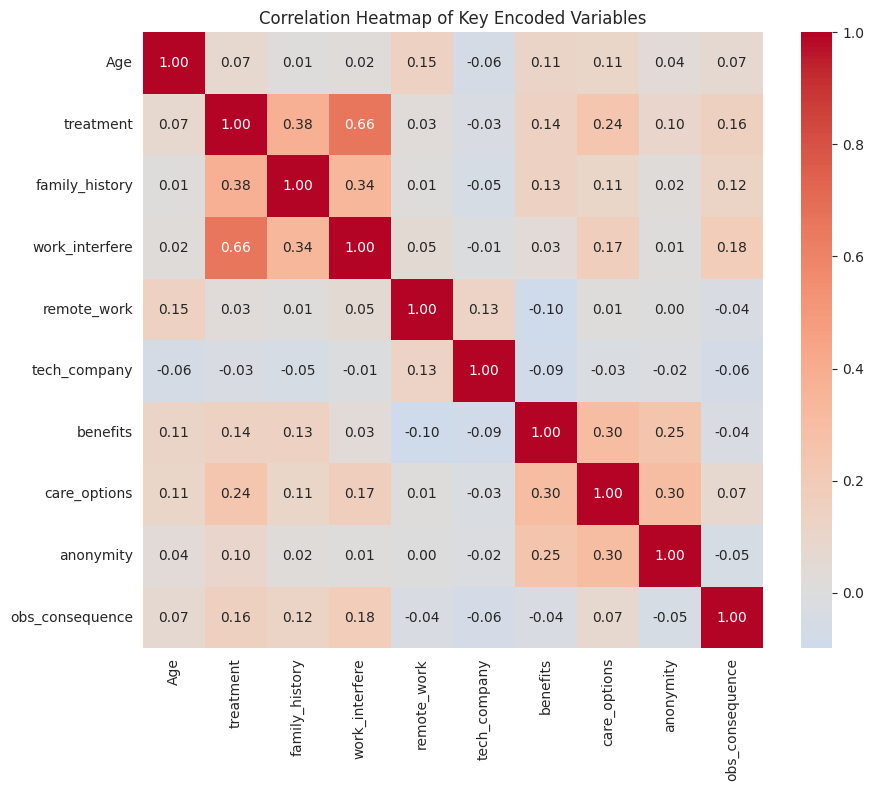

In [26]:
# Correlation Heatmap visualization code
corr_df = pd.DataFrame()
corr_df['Age'] = df['Age']
corr_df['treatment'] = df['treatment'].map({'Yes': 1, 'No': 0})
corr_df['family_history'] = df['family_history'].map({'Yes': 1, 'No': 0})
corr_df['work_interfere'] = df['work_interfere'].map(
    {'Not applicable': -1, 'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3})
corr_df['remote_work'] = df['remote_work'].map({'Yes': 1, 'No': 0})
corr_df['tech_company'] = df['tech_company'].map({'Yes': 1, 'No': 0})
corr_df['benefits'] = df['benefits'].map({'Yes': 1, "Don't know": 0.5, 'No': 0})
corr_df['care_options'] = df['care_options'].map({'Yes': 1, 'Not sure': 0.5, 'No': 0})
corr_df['anonymity'] = df['anonymity'].map({'Yes': 1, "Don't know": 0.5, 'No': 0})
corr_df['obs_consequence'] = df['obs_consequence'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Encoded Variables')
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to see, in one view, how every encoded variable relates to every other — essential after exploring each predictor individually in Charts 4-13.


##### 2. What is/are the insight(s) found from the chart?

This confirms the individual chart findings quantitatively: `work_interfere` has the strongest correlation with treatment (r = 0.49), followed by `family_history` (r = 0.38), then `care_options` (r = 0.24). `remote_work` and `tech_company` show almost no correlation with treatment (both near 0), confirming those aren't meaningful predictors in this dataset.


#### Chart - 15 - Pair Plot

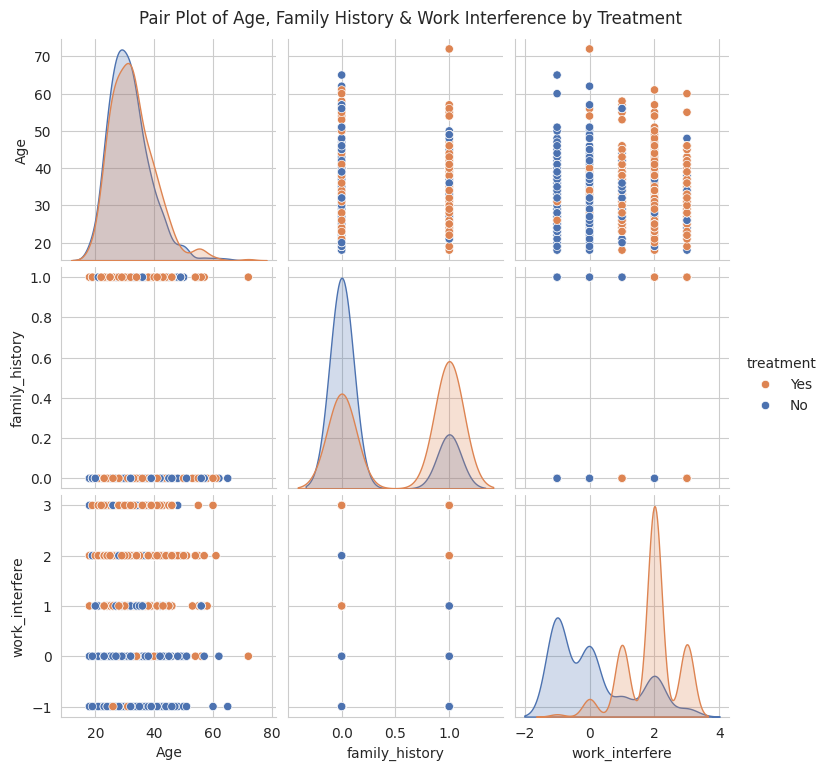

In [27]:
# Pair Plot visualization code
pairplot_df = corr_df[['Age', 'treatment', 'family_history', 'work_interfere']].copy()
pairplot_df['treatment'] = pairplot_df['treatment'].map({1: 'Yes', 0: 'No'})

sns.pairplot(pairplot_df, hue='treatment', palette=['#DD8452', '#4C72B0'], diag_kind='kde')
plt.suptitle('Pair Plot of Age, Family History & Work Interference by Treatment', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows pairwise relationships and distributions across several numeric/encoded variables at once, colored by the target — a good way to sanity-check whether the strongest correlates from the heatmap actually separate the two treatment groups visually.


##### 2. What is/are the insight(s) found from the chart?

The `work_interfere` distributions clearly separate by treatment status (higher interference values cluster with 'Yes'), visually confirming it as the strongest predictor. Age shows heavily overlapping distributions between the two treatment groups, confirming it's a weak predictor on its own, consistent with its near-zero correlation in the heatmap.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To improve mental health treatment-seeking among employees, the data suggests three concrete actions: (1) invest in **communicating** existing mental health benefits and care options clearly and repeatedly — the gap between employees who know about a benefit and those who say 'I don't know' is often as large as the gap between having a benefit and not having one at all; (2) run **targeted outreach for male employees**, who sought treatment at a noticeably lower rate (45.4%) than female (68.9%) and other-gender (92.3%) respondents in this sample, suggesting a possible stigma or awareness gap specific to that group; (3) don't rely on **company size** as a proxy for adequate mental health support — the data shows almost no relationship between headcount and treatment-seeking, so smaller companies shouldn't assume they're exempt from investing in this area, and larger ones shouldn't assume scale alone solves it.


# **Conclusion**

This EDA of the 2014 Mental Health in Tech survey found that the strongest predictors of an employee having sought treatment are self-reported work interference (r = 0.49) and family history of mental illness (r = 0.38) — both largely outside an employer's direct control. Among the factors employers *can* influence, clarity around care options and mental health benefits showed the clearest positive association with treatment-seeking, more so than anonymity protections, leave policy, or company size. A meaningful gender gap was also found, with male respondents seeking treatment at a lower rate than female and other-gender respondents. Overall, the data supports a clear, low-cost recommendation: employers get more value from clearly communicating the mental health support that already exists than from any single new benefit alone.


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***